In [45]:
import pandas as pd          # Manipulation de données
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree  # Arbre de décision
import matplotlib.pyplot as plt  # Visualisation
from sklearn.preprocessing import OrdinalEncoder


In [46]:
# Charger les données
import pandas as pd

df = pd.read_csv("C:/Users/Exauce Masenga/Documents/GitHub/Projet-tutore/Palmares/fichier finale.csv")

# Afficher les premières lignes
df.head()


,Id;CodeEcole2;Ecole;CodeProvinceEducationnelle;ProvinceEduc;CodeAnnee;Annee;CodeOption;Option;PartTot;PartH;PartF;ReussTot;ReussH;ReussF
0,1;41003017;;41;EQUATEUR 1;4;2022;101;LATIN-PHI...
1,2;41003027;COMPLEXE SCOLLEGEAIRE WIDAL SCHOOL;...
2,3;41004012;COLLEGEEGE ABBE LIOSSO;41;EQUATEUR ...
3,4;41004026;;41;EQUATEUR 1;4;2022;101;LATIN-PHI...
4,5;41005011;INSAINTITUTITUT DE WANGATA;41;EQUAT...


In [47]:
print(df.columns)


Index(['Id;CodeEcole2;Ecole;CodeProvinceEducationnelle;ProvinceEduc;CodeAnnee;Annee;CodeOption;Option;PartTot;PartH;PartF;ReussTot;ReussH;ReussF'], dtype='object')


In [43]:
df = pd.read_csv("C:/Users/Exauce Masenga/Documents/GitHub/Projet-tutore/Palmares/fichier finale.csv", sep=';')


In [19]:
print(df.columns)

Index(['Id', 'CodeEcole2', 'Ecole', 'CodeProvinceEducationnelle',
       'ProvinceEduc', 'CodeAnnee', 'Annee', 'CodeOption', 'Option', 'PartTot',
       'PartH', 'PartF', 'ReussTot', 'ReussH', 'ReussF'],
      dtype='object')


In [20]:
df['TauxReussite'] = (df['ReussTot'] / df['PartTot']) * 100


In [48]:
def performance(taux):
    if 0 <= taux <= 20:
        return 'Mauvais'
    elif 21 <= taux <= 40:
        return 'Mediocre'
    elif 41 <= taux <= 60:
        return 'Bien'
    elif 61 <= taux <= 80:
        return 'Très Bien'
    else:  # > 80
        return 'Excellent'

df['Classe'] = df['TauxReussite'].apply(performance)


KeyError: 'TauxReussite'

In [44]:
X = df[['ProvinceEduc', 'Ecole', 'Annee', 'Option']]
y = df['Classe']


KeyError: 'Classe'

In [26]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded = encoder.fit_transform(X)

In [27]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5)  # max_depth = limitation pour lisibilité
clf.fit(X, y)


DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [28]:
tree_rules = export_text(clf, feature_names=list(X.columns))
print(tree_rules)


|--- Annee <= 2021.50
|   |--- Annee <= 2019.50
|   |   |--- ProvinceEduc <= 2.50
|   |   |   |--- ProvinceEduc <= 1.50
|   |   |   |   |--- ProvinceEduc <= 0.50
|   |   |   |   |   |--- class: Mauvais
|   |   |   |   |--- ProvinceEduc >  0.50
|   |   |   |   |   |--- class: Mauvais
|   |   |   |--- ProvinceEduc >  1.50
|   |   |   |   |--- Option <= 0.50
|   |   |   |   |   |--- class: Excellent
|   |   |   |   |--- Option >  0.50
|   |   |   |   |   |--- class: Mauvais
|   |   |--- ProvinceEduc >  2.50
|   |   |   |--- ProvinceEduc <= 3.50
|   |   |   |   |--- Ecole <= 3417.00
|   |   |   |   |   |--- class: Mauvais
|   |   |   |   |--- Ecole >  3417.00
|   |   |   |   |   |--- class: Mauvais
|   |   |   |--- ProvinceEduc >  3.50
|   |   |   |   |--- ProvinceEduc <= 4.50
|   |   |   |   |   |--- class: Mauvais
|   |   |   |   |--- ProvinceEduc >  4.50
|   |   |   |   |   |--- class: Mauvais
|   |--- Annee >  2019.50
|   |   |--- ProvinceEduc <= 6.50
|   |   |   |--- ProvinceEduc <= 2

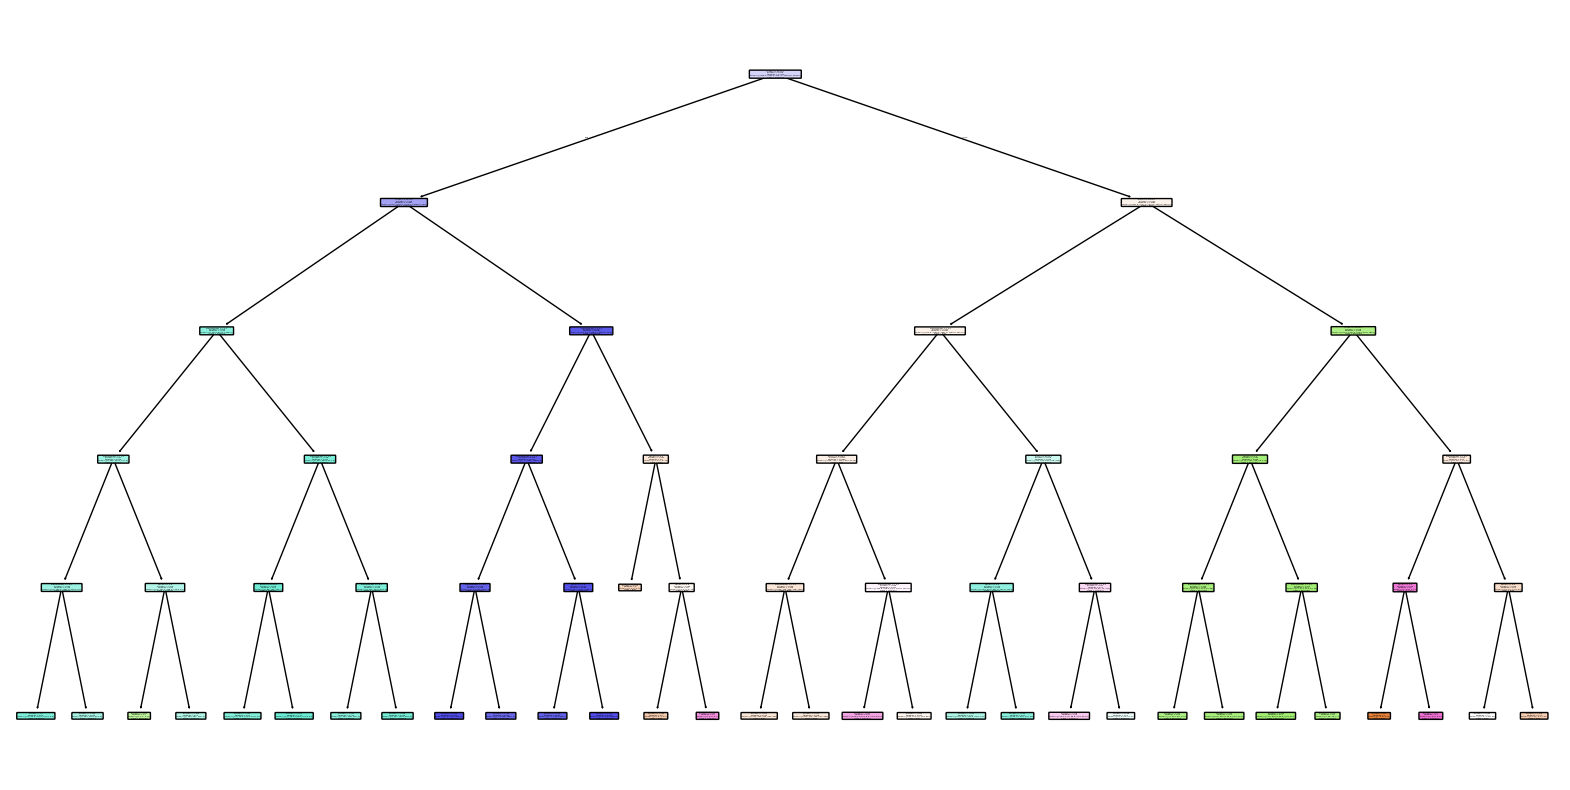

In [29]:
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True, rounded=True)
plt.show()


In [39]:
nouvelle_evaluation = pd.DataFrame({
    'ProvinceEduc': le_province.transform([1]),
    'Ecole': le_ecole.transform([4]),
    'Annee': [2024],
    'Option': le_option.transform([2]),
})

prediction = clf.predict(nouvelle_evaluation)
print("Prédiction :", prediction[0])


Prédiction : Bien


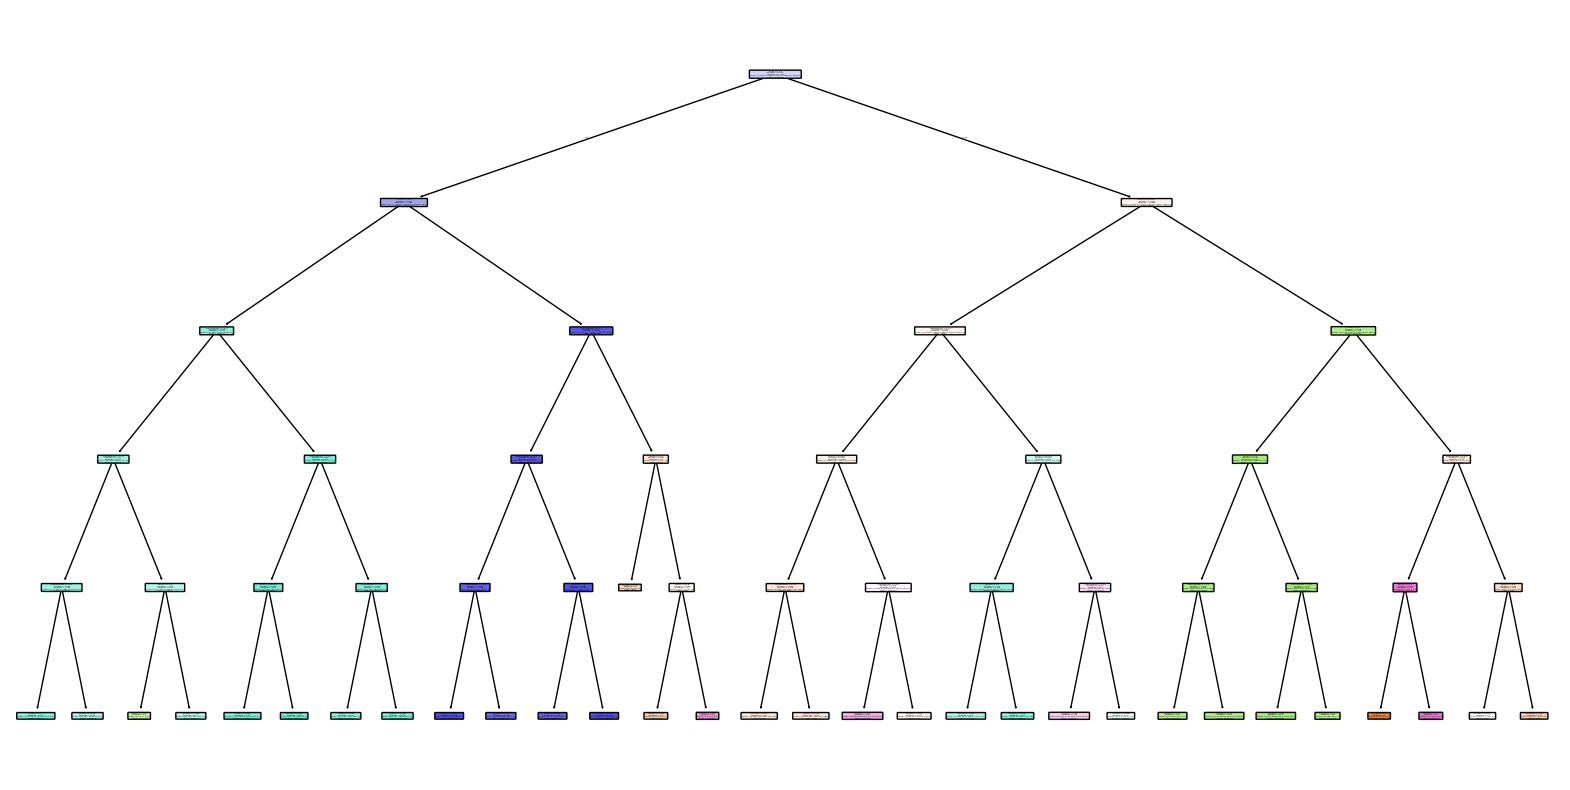

Prédiction : Mauvais


In [51]:
# 1️⃣ Importer les bibliothèques
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 2️⃣ Charger le fichier CSV avec séparateur ;
df = pd.read_csv("C:/Users/Exauce Masenga/Documents/GitHub/Projet-tutore/Palmares/fichier finale.csv", sep=';')

# 3️⃣ Calculer le taux de réussite
df['TauxReussite'] = (df['ReussTot'] / df['PartTot']) * 100

# 4️⃣ Créer la classe de performance
def performance(taux):
    if 0 <= taux <= 20:
        return 'Mauvais'
    elif 21 <= taux <= 40:
        return 'Mediocre'
    elif 41 <= taux <= 60:
        return 'Bien'
    elif 61 <= taux <= 80:
        return 'Très Bien'
    else:
        return 'Excellent'

df['Classe'] = df['TauxReussite'].apply(performance)

# 5️⃣ Préparer les variables explicatives
X = df[['ProvinceEduc', 'Ecole', 'Annee', 'Option']]
y = df['Classe']

# 6️⃣ Encoder les variables textuelles avec OrdinalEncoder
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded = encoder.fit_transform(X)

# 7️⃣ Créer et entraîner l'arbre de décision
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5)
clf.fit(X_encoded, y)

# 8️⃣ Visualiser l'arbre
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True, rounded=True)
plt.show()

# 9️⃣ Prédire pour de nouvelles données (valeurs textuelles autorisées)
nouvelle_evaluation = pd.DataFrame({
    'ProvinceEduc': ['KINSHASA-MONT AMBA'],
    'Ecole': ['INSTITUT MONT-AMBA 1'],
    'Annee': [2024],
    'Option': ['LATIN-PHILOSOPHIE'],
})

nouvelle_evaluation_encoded = encoder.transform(nouvelle_evaluation)
prediction = clf.predict(nouvelle_evaluation_encoded)
print("Prédiction :", prediction[0])
